<a href="https://colab.research.google.com/github/JotaPedroso/LSTMAnomalias/blob/main/LSTMAnomalias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Rede neural LSTM para detecção de anomalias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [2]:
dataset_train = pd.read_csv('Salestrain.csv')

In [3]:
dataset_train.shape

(96, 1)

In [4]:
dataset_train

,data
0,112
1,118
2,132
3,129
4,121
...,...
91,405
92,355
93,306
94,271


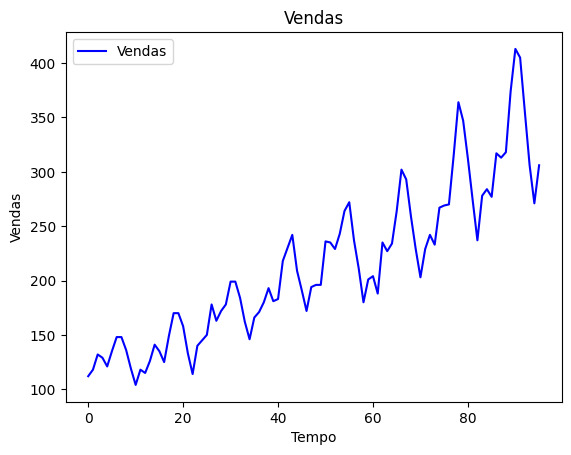

In [5]:
plt.plot(dataset_train, color='blue', label= 'Vendas')
plt.title("Vendas")
plt.xlabel("Tempo")
plt.ylabel("Vendas")
plt.legend(loc="upper left")
plt.show()

In [6]:
#Padronização dos dados
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(dataset_train)

In [7]:
#Construção da matriz da janela deslizante com os dados de treino
X_train = []
y_train = []
for i in range(90, len(training_set_scaled)):
    data = (training_set_scaled[i-90:i, 0])
    X_train.append(data)
    y_train.append(training_set_scaled[i,0])
X_train = np.array(X_train).reshape(-1,90,1)
y_train = np.array(y_train)

In [8]:
#Criação da rede neural sequencial
modelo = Sequential()
modelo.add(LSTM(units=100, return_sequences = True, input_shape=(X_train.shape[1],1)))
modelo.add(Dropout(0.2))
modelo.add(LSTM(units=100, return_sequences = True))
modelo.add(Dropout(0.2))
modelo.add(LSTM(units=100, return_sequences = True))
modelo.add(Dropout(0.2))
modelo.add(LSTM(units=100))
modelo.add(Dropout(0.2))
modelo.add(Dense(units=1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
#Compilação do modelo
modelo.compile(optimizer="adam", loss="mean_squared_error")
modelo.fit(X_train, y_train, epochs=300, batch_size=1)

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 164ms/step - loss: 0.4049
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - loss: 0.0919
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - loss: 0.0770
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - loss: 0.0834
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - loss: 0.0728
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - loss: 0.0418
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - loss: 0.0823
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - loss: 0.0574
Epoch 9/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - loss: 0.0649
Epoch 10/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - loss: 0.0596
Epoch 11/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 340ms/step - loss: 0.0589
Epoch 12/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - loss: 0.0401
Epoch 13/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - loss: 0.0537
Epoch 14/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - loss: 0.0612
Epoch 15/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - loss: 0.0524
Epoc

In [10]:
dataset_test = pd.read_csv("Salestest.csv")

In [11]:
dataset_test.shape

(48, 1)

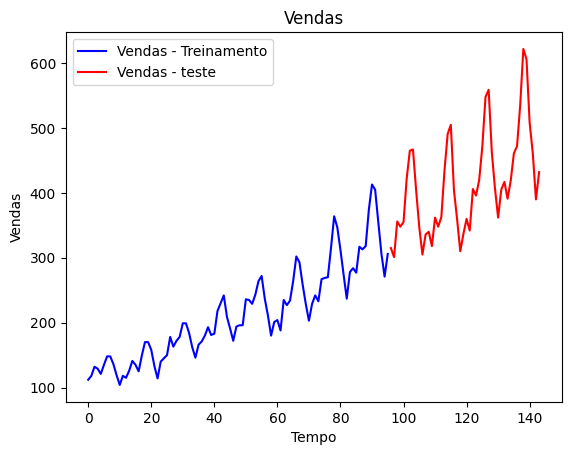

In [12]:
#Visualização dados treino e teste
train_values = dataset_train['data'].values
test_values = dataset_test['data'].values
total_values = np.concatenate((train_values, test_values), axis=0)
time_index = range(len(total_values))
plt.plot(time_index[:len(train_values)], train_values, color = 'blue', label= 'Vendas - Treinamento')
plt.plot(time_index[len(train_values):], test_values, color = 'red', label= 'Vendas - teste')
plt.title("Vendas")
plt.xlabel("Tempo")
plt.ylabel("Vendas")
plt.legend()
plt.show()

In [53]:
#Simulação de anomalias
dataset_test_anomalies = dataset_test.copy()
dataset_test_anomalies['data'] = dataset_test_anomalies['data'].astype(float)

dataset_test_anomalies.loc[:9,'data'] = 90
dataset_test_anomalies.loc[10:34, 'data'] = np.random.uniform(100,200, size=(25,))
dataset_test_anomalies.loc[35:, 'data'] = 90

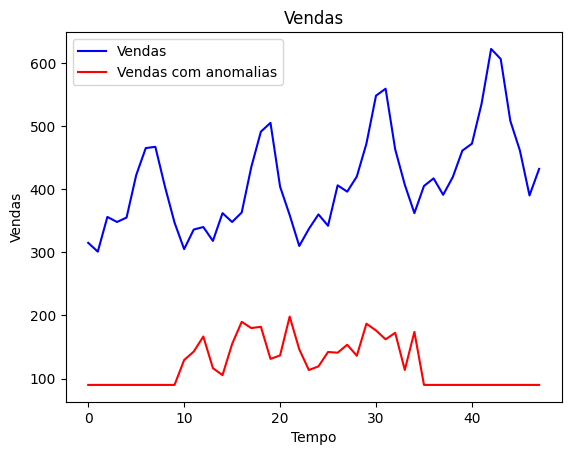

In [54]:
plt.plot(dataset_test, color='blue', label='Vendas')
plt.plot(dataset_test_anomalies, color='red', label='Vendas com anomalias')
plt.title('Vendas')
plt.xlabel('Tempo')
plt.ylabel('Vendas')
plt.legend()
plt.show()

In [58]:
dataset_total = pd.concat((dataset_train['data'], dataset_test['data']), axis=0)
inputs = dataset_total[len(dataset_total)-len(dataset_test)-90:]
inputs = pd.DataFrame(inputs, columns=['data'])
inputs = sc.transform(inputs)

In [59]:
dataset_total_anomalies = pd.concat((dataset_train['data'], dataset_test_anomalies['data']), axis=0)
inputs_anomalies = dataset_total_anomalies[len(dataset_total_anomalies)-len(dataset_test_anomalies)-90:]
inputs_anomalies = pd.DataFrame(inputs_anomalies, columns=['data'])
inputs_anomalies = sc.transform(inputs_anomalies)

In [60]:
#Construção da matriz da janela deslizante com os dados de teste
X_test = []
X_test_anomalies = []
for i in range(90, len(inputs)):
  X_test.append(inputs[i-90:i, 0])
  X_test_anomalies.append(inputs_anomalies[i-90:i, 0])
X_test, X_test_anomalies = np.array(X_test), np.array(X_test_anomalies)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
X_test_anomalies = np.reshape(X_test_anomalies, (X_test_anomalies.shape[0], X_test_anomalies.shape[1],1))

In [61]:
predicted_sales = modelo.predict(X_test)
predicted_sales = sc.inverse_transform(predicted_sales)

predicted_sales_anomalies = modelo.predict(X_test_anomalies)
predicted_sales_anomalies = sc.inverse_transform(predicted_sales_anomalies)

mse_test = mean_squared_error(test_values, predicted_sales)
mse_test_anomalies = mean_squared_error(test_values, predicted_sales_anomalies)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


In [62]:
# MSE dos dados e a previsão
print(f"MSE nos dados normais: {mse_test}")
print(f"MSE para os dados com anomalias: {mse_test_anomalies}")

MSE nos dados normais: 7740.77734375
MSE para os dados com anomalias: 22369.654296875


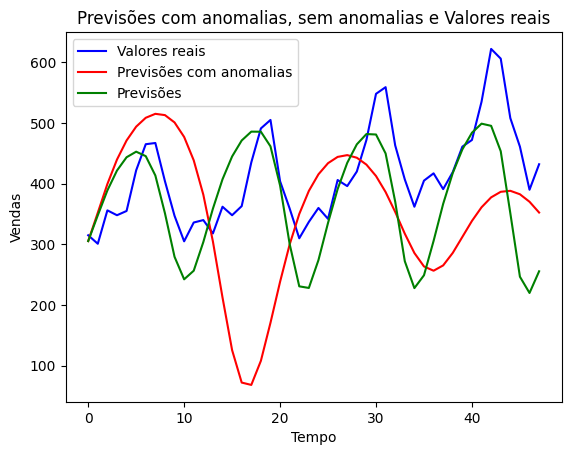

In [67]:
#Grafico de comparacao das previsões
plt.plot(test_values, color='blue', label='Valores reais')
plt.plot(predicted_sales_anomalies, color='red', label='Previsões com anomalias')
plt.plot(predicted_sales, color = 'green', label = 'Previsões')
plt.title('Previsões com anomalias, sem anomalias e Valores reais')
plt.xlabel('Tempo')
plt.ylabel('Vendas')
plt.legend()
plt.show()